# **TASK-ASTE-Rawdata**

##A_ Theo hướng Genarative
Bạn coi bài toán là "Dịch thuật". Input là câu review, Output là chuỗi văn bản chứa các cặp. Model tự học cách sinh ra từ và ghép cặp.

### 1_ Using `T5`

#####1.1_ Setup & Preparation

In [ ]:
# Cài đặt thư viện cần thiết
!pip install transformers datasets evaluate sentencepiece accelerate -q

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, Seq2SeqTrainingArguments, Seq2SeqTrainer, DataCollatorForSeq2Seq
import torch
import numpy as np
import re
import evaluate

# 1. Load Dataset ASTE
dataset = load_dataset("yhua219/EduRABSA_ASTE")

# Sử dụng BART-base (hoặc T5-base đều được)
model_checkpoint = "t5-small"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
model = AutoModelForSeq2SeqLM.from_pretrained(model_checkpoint)

print("--- Kiểm tra dữ liệu gốc ---")
print(dataset['train'][0])

train/data-00000-of-00001.arrow:   0%|          | 0.00/1.89M [00:00<?, ?B/s]

test/data-00000-of-00001.arrow:   0%|          | 0.00/1.22M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

--- Kiểm tra dữ liệu gốc ---
{'id': 'ASTE_101', 'task_type': 'ASTE', 'original_id': '2_11074_250', 'text': 'exams are full MC, you can kinda guess the answers using common sense. use libgen to get the textbook instead of paying$ 100 for it.', 'output': [{'aspect': 'exams', 'opinion': 'full MC', 'sentiment': 'Neutral'}, {'aspect': 'exams', 'opinion': 'you can kinda guess the answers using common sense', 'sentiment': 'Positive'}]}


In [ ]:
import pandas as pd

def extract_triplets(split):
    records = []
    for sample in split:
        for t in sample["output"]:
            records.append({
                "aspect": t["aspect"].lower(),
                "sentiment": t["sentiment"]
            })
    return pd.DataFrame(records)

df_train = extract_triplets(dataset["train"])


In [ ]:
def preprocess_function(examples):
    # 1. Input: Thêm Prefix (Quan trọng để T5 nhận diện task)
    # T5 hoạt động tốt nhất trên raw text (giữ nguyên dấu câu, viết hoa/thường)
    prefix = "extract triplets: "
    inputs = [prefix + str(doc) for doc in examples["text"]]

    # 2. Target: Format chuẩn đầu ra dạng chuỗi text
    # Mong muốn: "(aspect, opinion, sentiment); (aspect, opinion, sentiment)"
    targets = []

    # Map sentiment nếu dữ liệu gốc là số
    sentiment_map = {0: 'negative', 1: 'neutral', 2: 'positive'}

    for output in examples["output"]:
        triplet_strs = []
        # Kiểm tra phòng trường hợp output bị None hoặc rỗng
        if isinstance(output, list):
            for item in output:
                # Lấy giá trị, dùng 'null' nếu là implicit (ẩn)
                aspect = item.get('aspect', 'null')
                opinion = item.get('opinion', 'null')

                # Xử lý sentiment
                raw_sent = item.get('sentiment', 'neutral')
                sentiment = sentiment_map.get(raw_sent, str(raw_sent)) # Fallback về string nếu không nằm trong map

                triplet_strs.append(f"({aspect}, {opinion}, {sentiment})")

        # Nối các bộ ba bằng dấu chấm phẩy
        targets.append("; ".join(triplet_strs))

    # 3. Tokenize Inputs & Targets
    # max_length=256 là an toàn cho hầu hết review, có thể giảm xuống 128 nếu data ngắn để train nhanh hơn
    model_inputs = tokenizer(inputs, max_length=256, truncation=True)
    labels = tokenizer(text_target=targets, max_length=256, truncation=True)

    # [QUAN TRỌNG] Thay thế pad_token_id bằng -100
    # Điều này bảo HuggingFace bỏ qua các token này khi tính Loss
    labels["input_ids"] = [
        [(l if l != tokenizer.pad_token_id else -100) for l in label]
        for label in labels["input_ids"]
    ]

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

# --- CHẠY VÀ KIỂM TRA ---

print("Processing dataset for T5 ASTE...")
tokenized_datasets = dataset.map(preprocess_function, batched=True)

# Kiểm tra mẫu dữ liệu để đảm bảo mọi thứ đúng ý
print("\n--- Sample Processed Data (T5) ---")
idx = 0
print(f"🔹 Raw Input : {dataset['train'][idx]['text']}")
# Decode input để xem prefix đã vào chưa
print(f"🔹 T5 Input  : {tokenizer.decode(tokenized_datasets['train'][idx]['input_ids'], skip_special_tokens=True)}")
# Decode labels để xem format output (Lưu ý: -100 sẽ không được decode nên ta phải lọc ra để print thử)
labels_ids = [l for l in tokenized_datasets['train'][idx]['labels'] if l != -100]
print(f"🔹 Target    : {tokenizer.decode(labels_ids, skip_special_tokens=True)}")

Processing dataset for T5 ASTE...


Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]


--- Sample Processed Data (T5) ---
🔹 Raw Input : exams are full MC, you can kinda guess the answers using common sense. use libgen to get the textbook instead of paying$ 100 for it.
🔹 T5 Input  : extract triplets: exams are full MC, you can kinda guess the answers using common sense. use libgen to get the textbook instead of paying$ 100 for it.
🔹 Target    : (exams, full MC, Neutral); (exams, you can kinda guess the answers using common sense, Positive)


In [ ]:
print("\n--- CHECK KẾT QUẢ TIỀN XỬ LÝ ---")
# Chọn một mẫu có slang hoặc ký tự đặc biệt để kiểm tra
# Ví dụ mẫu 101 (chứa 'MC') hoặc 119 (chứa 'C:') nếu có trong train
idx = 0
raw_text = dataset['train'][idx]['text']
processed_input_ids = tokenized_datasets['train'][idx]['input_ids']
processed_target_ids = tokenized_datasets['train'][idx]['labels']

print(f"🔹 1. Raw Text Original: \n   {raw_text}")
print(f"🔹 2. T5 Input (Decoded): \n   {tokenizer.decode(processed_input_ids, skip_special_tokens=True)}")
print(f"🔹 3. T5 Target (Decoded): \n   {tokenizer.decode(processed_target_ids, skip_special_tokens=True)}")

# In thêm một mẫu ngẫu nhiên khác để check
print("\n--- Mẫu ngẫu nhiên khác ---")
idx = 5
print(f"🔹 Raw: {dataset['train'][idx]['text']}")
print(f"🔹 Input: {tokenizer.decode(tokenized_datasets['train'][idx]['input_ids'], skip_special_tokens=True)}")
print(f"🔹 Target: {tokenizer.decode(tokenized_datasets['train'][idx]['labels'], skip_special_tokens=True)}")


--- CHECK KẾT QUẢ TIỀN XỬ LÝ ---
🔹 1. Raw Text Original: 
   exams are full MC, you can kinda guess the answers using common sense. use libgen to get the textbook instead of paying$ 100 for it.
🔹 2. T5 Input (Decoded): 
   extract triplets: exams are full MC, you can kinda guess the answers using common sense. use libgen to get the textbook instead of paying$ 100 for it.
🔹 3. T5 Target (Decoded): 
   (exams, full MC, Neutral); (exams, you can kinda guess the answers using common sense, Positive)

--- Mẫu ngẫu nhiên khác ---
🔹 Raw: Fine university just nothing particularly stand out.
🔹 Input: extract triplets: Fine university just nothing particularly stand out.
🔹 Target: (university, Fine, Positive); (university, nothing particularly stand out, Neutral)


In [ ]:
!pip install evaluate rouge_score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=915e559fa815b2d96504301e31e89978cc3466af94357beadf2c37cbf914c8ce
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


#####1.2_ Split Val & Train

In [ ]:
# --- Cell 2 (Updated for ASTE): Split Val & Train T5 & Custom Metrics ---
from transformers import AutoModelForSeq2SeqLM, Seq2SeqTrainingArguments, Seq2SeqTrainer, DataCollatorForSeq2Seq
import torch
import evaluate
import numpy as np
import re

# 1. TÁCH VALIDATION TỪ TRAIN
# ---------------------------------------------------------
print(f"Original Train size: {len(tokenized_datasets['train'])}")

split_data = tokenized_datasets["train"].train_test_split(test_size=0.1, seed=42)

tokenized_datasets["train"] = split_data["train"]
tokenized_datasets["validation"] = split_data["test"]

print(f"New Train size: {len(tokenized_datasets['train'])}")
print(f"Created Validation size: {len(tokenized_datasets['validation'])}")
print(f"Held-out Test size: {len(tokenized_datasets['test'])}")
# ---------------------------------------------------------

Original Train size: 4000
New Train size: 3600
Created Validation size: 400
Held-out Test size: 2500


In [ ]:
# 2. Load Model
model_checkpoint = "t5-small"
model = AutoModelForSeq2SeqLM.from_pretrained(model_checkpoint)

# Load metric ROUGE (để tham khảo thêm)
rouge = evaluate.load("rouge")

# --- HÀM PHỤ TRỢ: PARSE KẾT QUẢ ASTE ---
def parse_aste_triplets(text):
    """
    Chuyển chuỗi output thành set các bộ 3.
    Input: "(screen, good, positive); (battery, bad, negative)"
    Output: {('screen', 'good', 'positive'), ('battery', 'bad', 'negative')}
    """
    triplets = set()
    try:
        # Regex bắt format (a, b, c)
        matches = re.findall(r'\(([^,]+),([^,]+),([^)]+)\)', text)
        for match in matches:
            # Strip whitespace và lowercase để so sánh chính xác hơn
            asp = match[0].strip().lower()
            opi = match[1].strip().lower()
            sent = match[2].strip().lower()
            triplets.add((asp, opi, sent))
    except:
        pass
    return triplets

# --- HÀM TÍNH METRICS (QUAN TRỌNG) ---
# --- HÀM TÍNH METRICS ĐÃ FIX LỖI OVERFLOW ---
def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    # 1. FIX QUAN TRỌNG: Xử lý -100 trong PREDICTIONS trước khi decode
    # Nếu không dòng này, tokenizer sẽ báo lỗi OverflowError khi gặp -100
    predictions = np.where(predictions != -100, predictions, tokenizer.pad_token_id)
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)

    # 2. Xử lý -100 trong LABELS (Bạn đã làm đúng phần này)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    # 3. Tính Precision, Recall, F1 cho ASTE Triplets
    tp = 0; fp = 0; fn = 0

    for pred_text, label_text in zip(decoded_preds, decoded_labels):
        pred_triplets = parse_aste_triplets(pred_text)
        label_triplets = parse_aste_triplets(label_text)

        # Tính giao của 2 tập hợp (số lượng đúng)
        common = pred_triplets.intersection(label_triplets)

        tp += len(common)
        fp += len(pred_triplets - label_triplets)
        fn += len(label_triplets - pred_triplets)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    # 4. Tính ROUGE (tham khảo)
    rouge_result = rouge.compute(predictions=decoded_preds, references=decoded_labels)

    return {
        "aste_precision": round(precision, 4),
        "aste_recall": round(recall, 4),
        "aste_f1": round(f1, 4),
        "rouge1": round(rouge_result['rouge1'], 4)
    }

# 3. Config Training
batch_size = 8
num_epochs = 10

args = Seq2SeqTrainingArguments(
    output_dir="t5-aste-edurabsa", # Đổi tên folder output
    predict_with_generate=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=num_epochs,
    load_best_model_at_end=True,
    report_to="none",
    # --- QUAN TRỌNG: Đổi metric tối ưu sang F1 ---
    metric_for_best_model="aste_f1",
    greater_is_better=True,
    # ---------------------------------------------

    learning_rate=3e-4,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    weight_decay=0.01,
    fp16=torch.cuda.is_available(),
    generation_max_length=256, # ASTE output dài hơn AOPE, cần đảm bảo đủ dài
    logging_steps=50,
)

# 4. Data Collator & Trainer
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

trainer = Seq2SeqTrainer(
    model=model,
    args=args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

# 6. Start Training
print("\n--- START TRAINING ASTE WITH T5 ---")
trainer.train()

# 7. Save Final Model
save_path = "saved_models/t5_aste_best"
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)
print(f"Training Finished! Best model saved at: {save_path}")

/tmp/ipython-input-1137994981.py:100: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(



--- START TRAINING ASTE WITH T5 ---


Epoch,Training Loss,Validation Loss,Aste Precision,Aste Recall,Aste F1,Rouge1
1,0.548200,0.438792,0.328300,0.326200,0.327300,0.704500
2,0.440000,0.379856,0.397900,0.380500,0.389000,0.732300
3,0.353500,0.371375,0.406300,0.385700,0.395700,0.754000
4,0.313700,0.361378,0.407900,0.415700,0.411800,0.766700
5,0.289100,0.360432,0.431000,0.431300,0.431200,0.772300
6,0.256400,0.356558,0.429300,0.433000,0.431200,0.780200
7,0.230400,0.359040,0.436500,0.438200,0.437300,0.782800
8,0.211000,0.372736,0.430800,0.440000,0.435300,0.784100
9,0.191900,0.370350,0.446900,0.444600,0.445700,0.783000
10,0.190200,0.373870,0.446400,0.454400,0.450400,0.786600


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


Training Finished! Best model saved at: saved_models/t5_aste_best


#####1.3_ Đánh giá trên Test

In [ ]:
import re
import numpy as np
from scipy.optimize import linear_sum_assignment

class ASTEEvaluator:
    def __init__(self):
        self.sentiment_map = {
            'pos': 'positive', 'positive': 'positive', '2': 'positive', '2.0': 'positive',
            'neu': 'neutral', 'neutral': 'neutral', '1': 'neutral', '1.0': 'neutral',
            'neg': 'negative', 'negative': 'negative', '0': 'negative', '0.0': 'negative'
        }

    def normalize_sentiment(self, sent):
        if isinstance(sent, (int, float)):
            sent = str(int(sent))
        return self.sentiment_map.get(str(sent).strip().lower(), 'neutral')

    def parse_triplets(self, text):
        """Parse chuỗi thành list các dict để dễ truy cập theo key"""
        triplets = []
        if not isinstance(text, str):
            return triplets

        # Regex tìm nội dung trong ngoặc đơn
        raw_triplets = re.findall(r'\(([^)]+)\)', text)

        for item in raw_triplets:
            try:
                # Tách từ phải qua trái để an toàn với Aspect chứa dấu phẩy
                parts = item.rsplit(',', 2)
                if len(parts) < 3: continue

                aspect = parts[0].strip().lower()
                opinion = parts[1].strip().lower()
                sentiment = self.normalize_sentiment(parts[2])

                if aspect and opinion:
                    triplets.append({
                        'aspect': aspect,
                        'opinion': opinion,
                        'sentiment': sentiment
                    })
            except:
                continue
        return triplets

    # --- CÁC HÀM PHỤ TRỢ CHO FTS (CƠ CHẾ 1) ---

    def _lcs(self, s1, s2):
        """Tính độ dài chuỗi con chung dài nhất (Longest Common Subsequence)"""
        m, n = len(s1), len(s2)
        dp = [[0] * (n + 1) for _ in range(m + 1)]
        for i in range(1, m + 1):
            for j in range(1, n + 1):
                if s1[i - 1] == s2[j - 1]:
                    dp[i][j] = dp[i - 1][j - 1] + 1
                else:
                    dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])
        return dp[m][n]

    def _rouge_l_f1(self, pred_str, label_str):
        """Tính điểm Rouge-L F1 giữa dự đoán và nhãn"""
        p_tokens = pred_str.split()
        l_tokens = label_str.split()

        if not p_tokens or not l_tokens: return 0.0

        lcs_len = self._lcs(p_tokens, l_tokens)

        precision = lcs_len / len(p_tokens)
        recall = lcs_len / len(l_tokens)

        if precision + recall == 0: return 0.0
        return 2 * precision * recall / (precision + recall)

    def _get_threshold(self, label_str):
        """Ngưỡng động dựa trên độ dài nhãn gốc"""
        g_len = len(label_str.split())
        if g_len <= 2: return 0.5
        if 3 <= g_len <= 4: return 0.6
        return 0.7

    def _check_hallucination(self, text, source_text):
        """Kiểm tra xem text dự đoán có tồn tại trong câu gốc không"""
        return text.lower() in source_text.lower()

    # --- [BỔ SUNG QUAN TRỌNG] HÀM EXACT MATCH ---
    # Hàm này bị thiếu trong code cũ của bạn, gây ra lỗi AttributeError ở Cell 3
    def compute_scores_exact_match(self, pred_texts, label_texts):
        """Tính điểm Exact Match (Truyền thống)"""
        tp_total = 0
        fp_total = 0
        fn_total = 0

        for pred, label in zip(pred_texts, label_texts):
            # Chuyển về set of tuples để tính exact match
            pred_set = set([(t['aspect'], t['opinion'], t['sentiment']) for t in self.parse_triplets(pred)])
            label_set = set([(t['aspect'], t['opinion'], t['sentiment']) for t in self.parse_triplets(label)])

            common = pred_set & label_set
            tp_total += len(common)
            fp_total += len(pred_set - label_set)
            fn_total += len(label_set - pred_set)

        epsilon = 1e-10
        precision = tp_total / (tp_total + fp_total + epsilon)
        recall = tp_total / (tp_total + fn_total + epsilon)
        f1 = 2 * (precision * recall) / (precision + recall + epsilon)

        return {
            "precision": round(precision, 4), "recall": round(recall, 4), "f1": round(f1, 4),
            "tp": tp_total, "fp": fp_total, "fn": fn_total
        }

    # --- HÀM TÍNH TOÁN FTS-OBP (CƠ CHẾ 2) ---

    def compute_scores_fts_obp(self, pred_texts, label_texts, source_texts, verbose=False):
        """Tính điểm theo chuẩn FTS-OBP."""
        tp_total = 0
        fp_total = 0
        fn_total = 0

        mismatches = []

        for idx, (pred_str, label_str, src_str) in enumerate(zip(pred_texts, label_texts, source_texts)):
            preds = self.parse_triplets(pred_str)
            labels = self.parse_triplets(label_str)

            n_p = len(preds)
            n_l = len(labels)

            score_matrix = np.zeros((n_p, n_l))
            pass_threshold_matrix = np.zeros((n_p, n_l), dtype=bool)

            for i, p in enumerate(preds):
                for j, l in enumerate(labels):
                    # 1. Check Exact Match Sentiment
                    if p['sentiment'] != l['sentiment']:
                        score_matrix[i, j] = 0.0
                        continue

                    # 2. Check Hallucination
                    if not self._check_hallucination(p['aspect'], src_str) or \
                       not self._check_hallucination(p['opinion'], src_str):
                        score_matrix[i, j] = 0.0
                        continue

                    # 3. Tính Rouge-L F1
                    score_asp = self._rouge_l_f1(p['aspect'], l['aspect'])
                    score_opi = self._rouge_l_f1(p['opinion'], l['opinion'])

                    # 4. Lấy ngưỡng động
                    thresh_asp = self._get_threshold(l['aspect'])
                    thresh_opi = self._get_threshold(l['opinion'])

                    # 5. Kiểm tra ngưỡng
                    if score_asp >= thresh_asp and score_opi >= thresh_opi:
                        score_matrix[i, j] = (score_asp + score_opi) / 2
                        pass_threshold_matrix[i, j] = True
                    else:
                        score_matrix[i, j] = (score_asp + score_opi) / 2

            # OBP - Hungarian Algorithm
            if n_p > 0 and n_l > 0:
                row_ind, col_ind = linear_sum_assignment(score_matrix, maximize=True)
            else:
                row_ind, col_ind = [], []

            curr_tp = 0
            for r, c in zip(row_ind, col_ind):
                if pass_threshold_matrix[r, c]:
                    curr_tp += 1

            tp_total += curr_tp
            fp_total += (n_p - curr_tp)
            fn_total += (n_l - curr_tp)

            if verbose and (n_p - curr_tp > 0 or n_l - curr_tp > 0):
                 mismatches.append({
                    "id": idx, "src": src_str, "pred": pred_str, "label": label_str, "tp": curr_tp
                })

        epsilon = 1e-10
        precision = tp_total / (tp_total + fp_total + epsilon)
        recall = tp_total / (tp_total + fn_total + epsilon)
        f1 = 2 * (precision * recall) / (precision + recall + epsilon)

        return {
            "precision": round(precision, 4), "recall": round(recall, 4), "f1": round(f1, 4),
            "tp": tp_total, "fp": fp_total, "fn": fn_total, "mismatches": mismatches
        }


# --- TEST CODE ---
if __name__ == "__main__":
    evaluator = ASTEEvaluator()

    # Dữ liệu giả lập
    # Câu 1: Dự đoán "màn hình" vs Nhãn "màn hình hiển thị" -> FTS sẽ chấp nhận nếu đủ điểm
    source_texts = [
        "Màn hình hiển thị rất sắc nét nhưng pin hơi yếu.",
        "Giá sản phẩm này quá đắt so với chất lượng.",
        "Dịch vụ tốt."
    ]

    ground_truth = [
        "(Màn hình hiển thị, sắc nét, Positive); (Pin, yếu, Negative)",
        "(Giá sản phẩm, quá đắt, Negative)",
        "(Dịch vụ, tốt, Positive)"
    ]

    predictions = [
        "(màn hình, sắc nét, pos); (pin, yếu, neg)", # 'màn hình' khớp 'màn hình hiển thị' qua FTS
        "(Giá, đắt, Positive)", # Sai sentiment (Positive vs Negative) -> Sẽ là FP và FN
        "(Dịch vụ, tốt, Positive); (Wifi, mạnh, Positive)" # Wifi ảo giác (không có trong source) -> FP
    ]

    print("--- ĐÁNH GIÁ FTS-OBP ---")
    results = evaluator.compute_scores_fts_obp(predictions, ground_truth, source_texts, verbose=True)

    print(f"PRECISION : {results['precision']}")
    print(f"RECALL    : {results['recall']}")
    print(f"F1 SCORE  : {results['f1']}")
    print(f"Chi tiết  : TP={results['tp']}, FP={results['fp']}, FN={results['fn']}")

    print("\n--- PHÂN TÍCH ---")
    # Giải thích tại sao:
    # Câu 1:
    #   - (màn hình, sắc nét) vs (Màn hình hiển thị, sắc nét): Rouge-L Aspect cao, Opinion max, Sent khớp -> TP
    #   - (pin, yếu) vs (Pin, yếu): TP
    # Câu 2:
    #   - Sai sentiment -> Matrix score = 0 -> Không ghép hoặc ghép rác -> FP, FN.
    # Câu 3:
    #   - Wifi không có trong source text -> Check Hallucination loại bỏ -> FP.

--- ĐÁNH GIÁ FTS-OBP ---
PRECISION : 0.6
RECALL    : 0.75
F1 SCORE  : 0.6667
Chi tiết  : TP=3, FP=2, FN=1

--- PHÂN TÍCH ---


Loading best model from: saved_models/t5_aste_best ...
⏳ Đang tải tập Test...


/tmp/ipython-input-2112336884.py:69: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  test_trainer = Seq2SeqTrainer(



--- ĐANG ĐÁNH GIÁ TRÊN TẬP TEST ---



 📊 KẾT QUẢ 1: EXACT MATCH (TRUYỀN THỐNG)
Precision : 0.4332
Recall    : 0.4390
F1-Score  : 0.4361
TP: 4575, FP: 5986, FN: 5846

 📊 KẾT QUẢ 2: FTS-OBP (LINH HOẠT)
Precision : 0.4994
Recall    : 0.5118
F1-Score  : 0.5055
TP: 5368, FP: 5381, FN: 5121
--------------------------------------------------


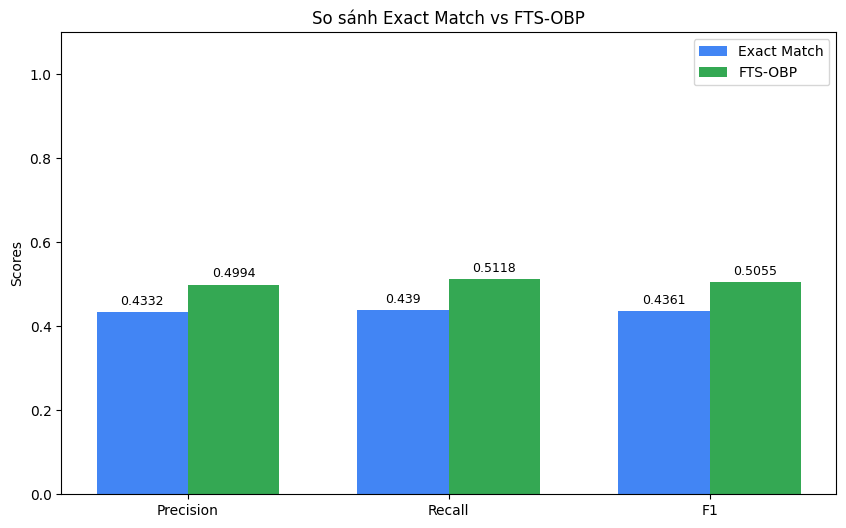


--- 5 MẪU DỰ ĐOÁN ĐẦU TIÊN ---
Review: She will only accept. docx forms in microsoft 2007. But, surprise, mason doesn't use vista or microsoft 2007! They still use XP, and microsoft 2006. This professor is useless and unreasonable. TAKE ANOTHER PROFESSOR
Ref   : (This professor, useless, negative); (This professor, unreasonable, negative); (null, TAKE ANOTHER PROFESSOR, negative)
Pred  : (This professor, will only accept, Negative); (this professor, useless and unreasonable, Negative)
----------------------------------------
Review: Great Teacher! Learned a lot! If coming to class isn't your thing take her. But if you do come to class she does know her stuff! Very accommodating and understanding. Good stuff. Highly recommended. Better than the rest!
Ref   : (Teacher, Great, positive); (Teacher, Good stuff, positive); (null, Learned a lot, positive); (Teacher, take her, positive); (Teacher, know her stuff, positive); (Teacher, Very accommodating and understanding, positive); (Teacher, 

In [ ]:
# =========================================================
# PHẦN 2: LOAD MODEL & PREPARE DATA
# =========================================================

# 1. LOAD MODEL
save_path = "saved_models/t5_aste_best"
print(f"Loading best model from: {save_path} ...")
try:
    best_model = AutoModelForSeq2SeqLM.from_pretrained(save_path).to("cuda" if torch.cuda.is_available() else "cpu")
    best_tokenizer = AutoTokenizer.from_pretrained(save_path)
except Exception as e:
    print(f"Lỗi load model: {e}")
    raise e

# 2. PREPROCESS FUNCTION (TỐI GIẢN CHO T5)
def preprocess_function_simple(examples):
    # Prefix giúp T5 hiểu task
    prefix = "extract triplets: "
    inputs = [prefix + str(text) for text in examples["text"]]

    targets = []
    sentiment_map = {0: 'negative', 1: 'neutral', 2: 'positive'}

    for output in examples["output"]:
        triplet_strs = []
        if isinstance(output, list):
            for item in output:
                # Lấy dữ liệu thô, không clean gì thêm
                aspect = item.get('aspect', 'null')
                opinion = item.get('opinion', 'null')
                raw_sent = item.get('sentiment', 'neutral')

                # Chỉ xử lý sentiment nếu là số
                if isinstance(raw_sent, int):
                    sentiment = sentiment_map.get(raw_sent, 'neutral')
                else:
                    sentiment = str(raw_sent).lower()

                triplet_strs.append(f"({aspect}, {opinion}, {sentiment})")
            targets.append("; ".join(triplet_strs))
        else:
            targets.append("")

    model_inputs = best_tokenizer(inputs, max_length=256, truncation=True)
    labels = best_tokenizer(text_target=targets, max_length=256, truncation=True)
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

# 3. LOAD DATA & MAP
print("⏳ Đang tải tập Test...")
raw_dataset = load_dataset("yhua219/EduRABSA_ASTE")
tokenized_datasets = raw_dataset.map(preprocess_function_simple, batched=True)
data_collator = DataCollatorForSeq2Seq(tokenizer=best_tokenizer, model=best_model)

# =========================================================
# PHẦN 3: PREDICT & EVALUATE
# =========================================================

# 1. CONFIG TRAINER
test_args = Seq2SeqTrainingArguments(
    output_dir="temp_aste_test_output",
    do_train=False, do_eval=False,
    generation_max_length=256,
    per_device_eval_batch_size=16,
    predict_with_generate=True,
    fp16=torch.cuda.is_available(),
)

test_trainer = Seq2SeqTrainer(
    model=best_model, args=test_args,
    data_collator=data_collator, tokenizer=best_tokenizer
)

print("\n--- ĐANG ĐÁNH GIÁ TRÊN TẬP TEST ---")
test_dataset = tokenized_datasets["test"]
predictions = test_trainer.predict(test_dataset)

# 2. DECODE KẾT QUẢ
preds_tokens = predictions.predictions
labels_tokens = predictions.label_ids
# Fix -100
labels_tokens = np.where(labels_tokens != -100, labels_tokens, best_tokenizer.pad_token_id)
preds_tokens = np.where(preds_tokens != -100, preds_tokens, best_tokenizer.pad_token_id)

decoded_preds = best_tokenizer.batch_decode(preds_tokens, skip_special_tokens=True)
decoded_labels = best_tokenizer.batch_decode(labels_tokens, skip_special_tokens=True)
source_texts = raw_dataset['test']['text'] # Lấy text gốc để check FTS

# 3. TÍNH ĐIỂM
evaluator = ASTEEvaluator()

# --- A. Exact Match (Truyền thống) ---
metrics_em = evaluator.compute_scores_exact_match(decoded_preds, decoded_labels)

print("\n" + "="*50)
print(" 📊 KẾT QUẢ 1: EXACT MATCH (TRUYỀN THỐNG)")
print("="*50)
print(f"Precision : {metrics_em['precision']:.4f}")
print(f"Recall    : {metrics_em['recall']:.4f}")
print(f"F1-Score  : {metrics_em['f1']:.4f}")
print(f"TP: {metrics_em['tp']}, FP: {metrics_em['fp']}, FN: {metrics_em['fn']}")

# --- B. FTS-OBP (Nâng cao) ---
metrics_fts = evaluator.compute_scores_fts_obp(decoded_preds, decoded_labels, source_texts)

print("\n" + "="*50)
print(" 📊 KẾT QUẢ 2: FTS-OBP (LINH HOẠT)")
print("="*50)
print(f"Precision : {metrics_fts['precision']:.4f}")
print(f"Recall    : {metrics_fts['recall']:.4f}")
print(f"F1-Score  : {metrics_fts['f1']:.4f}")
print(f"TP: {metrics_fts['tp']}, FP: {metrics_fts['fp']}, FN: {metrics_fts['fn']}")
print("-" * 50)

# 4. TRỰC QUAN HÓA SO SÁNH
metrics_names = ['Precision', 'Recall', 'F1']
x = np.arange(len(metrics_names))
width = 0.35

vals_em = [metrics_em['precision'], metrics_em['recall'], metrics_em['f1']]
vals_fts = [metrics_fts['precision'], metrics_fts['recall'], metrics_fts['f1']]

plt.figure(figsize=(10, 6))
bar1 = plt.bar(x - width/2, vals_em, width, label='Exact Match', color='#4285F4')
bar2 = plt.bar(x + width/2, vals_fts, width, label='FTS-OBP', color='#34A853')

plt.ylabel('Scores')
plt.title('So sánh Exact Match vs FTS-OBP')
plt.xticks(x, metrics_names)
plt.legend()
plt.ylim(0, 1.1)

# Thêm text lên cột
def add_labels(bars):
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 4), ha='center', va='bottom', fontsize=9)

add_labels(bar1)
add_labels(bar2)
plt.show()

# 5. IN MẪU KẾT QUẢ
print("\n--- 5 MẪU DỰ ĐOÁN ĐẦU TIÊN ---")
for i in range(5):
    print(f"Review: {source_texts[i]}")
    print(f"Ref   : {decoded_labels[i]}")
    print(f"Pred  : {decoded_preds[i]}")
    print("-" * 40)

#####1.4_ Test thử vài mẫu

In [ ]:
import random

print("\n--- KIỂM TRA MẪU NGẪU NHIÊN TỪ TẬP TEST (ASTE) ---")

# 1. Config số lượng mẫu muốn xem
num_samples = 5
total_samples = len(decoded_preds)
if num_samples > total_samples:
    num_samples = total_samples

# 2. Chọn ngẫu nhiên index
random_indices = random.sample(range(total_samples), num_samples)

# 3. Lấy input_ids từ dataset test để decode lại thành văn bản gốc
# Lưu ý: 'tokenized_datasets' là biến dataset bạn đã xử lý ở các bước trước
test_input_ids = tokenized_datasets['test']['input_ids']

for i in random_indices:
    # A. Decode Input Text (Review gốc)
    # Dùng best_tokenizer để đảm bảo đúng vocab
    input_text = best_tokenizer.decode(test_input_ids[i], skip_special_tokens=True)

    pred = decoded_preds[i]
    label = decoded_labels[i]

    print(f"\nExample #{i}:")
    print(f"📝 Review Text: {input_text}")
    print(f"✅ Ground Truth: {label}")
    print(f"🤖 Prediction  : {pred}")

    # B. So sánh tập hợp bộ 3 (Set of Triplets)
    # Sử dụng hàm parse_aste_triplets đã định nghĩa ở phần trước
    pred_triplets = parse_aste_triplets(pred)
    label_triplets = parse_aste_triplets(label)

    if pred_triplets == label_triplets:
        print("=> Đánh giá: CHÍNH XÁC HOÀN TOÀN 🎉")
    else:
        print("=> Đánh giá: SAI ❌")

        # C. Phân tích lỗi (Optional - Giúp debug tốt hơn)
        missing = label_triplets - pred_triplets # Có trong nhãn nhưng model không đoán ra
        extra = pred_triplets - label_triplets   # Model đoán thừa hoặc sai

        if len(missing) > 0:
            print(f"   ⚠️  Thiếu (FN): {missing}")
        if len(extra) > 0:
            print(f"   ⚠️  Thừa/Sai (FP): {extra}")

    print("-" * 60)


--- KIỂM TRA MẪU NGẪU NHIÊN TỪ TẬP TEST (ASTE) ---

Example #571:
📝 Review Text: extract triplets: Incredibly enthusiastic. Very nice guy willing to work with you to make sure you can do your very best. I loved attending this class.
✅ Ground Truth: (null, Incredibly enthusiastic, positive); (null, Very nice guy, positive); (null, willing to work with you to make sure you can do your very best, positive); (this class, loved attending, positive)
🤖 Prediction  : (null, Incredibly enthusiastic, Positive); (null, Very nice guy, Positive); (null, willing to work with you to make sure you can do your very best, Positive); (this class, loved attending, Positive)
=> Đánh giá: CHÍNH XÁC HOÀN TOÀN 🎉
------------------------------------------------------------

Example #419:
📝 Review Text: extract triplets: Perfect course note, very easy to understand.
✅ Ground Truth: (course note, Perfect, positive); (course note, very easy to understand, positive)
🤖 Prediction  : (course note, Perfect, Positive

In [ ]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# --- CẤU HÌNH HIỂN THỊ ---
torch.set_printoptions(precision=4, sci_mode=False, linewidth=120)
np.set_printoptions(precision=4, suppress=True, linewidth=120)

# --- 1. LOAD MODEL ---
model_path = "saved_models/t5_aste_best"
try:
    print(f"🔄 Đang load model từ: {model_path}...")
    debug_model = AutoModelForSeq2SeqLM.from_pretrained(model_path)
    debug_tokenizer = AutoTokenizer.from_pretrained(model_path)
except:
    print("⚠️ Không tìm thấy model đã lưu, sử dụng model hiện tại trong RAM.")
    debug_model = model
    debug_tokenizer = tokenizer

# --- 2. CHUẨN BỊ DỮ LIỆU ---
sample_text = "Not so easy class; great instructor!"
print("\n" + "="*60)
print(f"INPUT SENTENCE: {sample_text}")
print("="*60 + "\n")

# Tokenize Encoder Input
inputs = debug_tokenizer(sample_text, return_tensors="pt")
input_ids = inputs.input_ids

# --- HÀM HỖ TRỢ IN ẤN ---
def print_vector_values(name, tensor):
    """In 10 giá trị đầu tiên của token CUỐI CÙNG (đang được xử lý)"""
    # tensor shape: [Batch, Seq_Len, Hidden]
    # Ta chỉ quan tâm token cuối cùng (-1) vì đó là từ đang được sinh ra
    values = tensor[0, -1, :].detach().cpu().numpy()

    v_max = tensor.max().item()
    v_mean = tensor.mean().item()

    print(f"   📍 {name:<25} | Max: {v_max:6.2f} | Sample: {values}")

# ==============================================================================
# GIAI ĐOẠN 1: ENCODER (CHẠY 1 LẦN DUY NHẤT)
# ==============================================================================
print("🚀 --- GIAI ĐOẠN 1: ENCODER (Đọc hiểu ngữ cảnh) ---")
print("   * Encoder chỉ chạy đúng 1 lần để mã hóa câu input.")
print("-" * 80)

debug_model.eval()
with torch.no_grad():
    # Gọi riêng phần Encoder
    # output_hidden_states=True để lấy tensor từng lớp
    encoder_outputs_bundle = debug_model.encoder(
        input_ids=input_ids,
        output_hidden_states=True
    )

# In thông tin các lớp Encoder
encoder_states = encoder_outputs_bundle.hidden_states
for i, state in enumerate(encoder_states):
    layer_name = "Embedding" if i == 0 else f"Enc Block #{i}"
    print_vector_values(layer_name, state)

print("\n✅ Encoder đã xong! Output này sẽ được giữ nguyên và dùng lại cho mọi bước Decoder.\n")


# ==============================================================================
# GIAI ĐOẠN 2: DECODER LOOP (AUTOREGRESSIVE)
# ==============================================================================
print("🚀 --- GIAI ĐOẠN 2: DECODER LOOP (Sinh từng từ một) ---")

# 1. Khởi tạo Decoder Input với token bắt đầu (thường là Pad token = 0)
decoder_input_ids = torch.tensor([[debug_model.config.decoder_start_token_id]])

# Giới hạn chạy thử 5 bước (để không in quá dài)
MAX_STEPS = 30

for step in range(MAX_STEPS):
    print(f"\n🔄 BƯỚC {step + 1} (Step {step+1})")

    # Hiển thị input hiện tại của Decoder
    current_input_text = debug_tokenizer.decode(decoder_input_ids[0], skip_special_tokens=False)
    print(f"   📝 Decoder Input hiện tại: {decoder_input_ids.tolist()} -> '{current_input_text}'")

    with torch.no_grad():
        # Gọi Model (Decoder sẽ dùng encoder_outputs đã tính ở trên)
        outputs = debug_model(
            encoder_outputs=encoder_outputs_bundle, # Tái sử dụng Encoder
            decoder_input_ids=decoder_input_ids,
            output_hidden_states=True
        )

    # A. SOI CÁC LỚP DECODER (Chỉ xem token mới nhất vừa sinh ra)
    print("   🔍 Luồng dữ liệu qua các lớp Decoder (Token cuối):")
    decoder_states = outputs.decoder_hidden_states
    for i, state in enumerate(decoder_states):
        layer_name = "Emb" if i == 0 else f"Dec Blk #{i}"
        # state có shape [1, seq_len, 512]. Ta lấy seq_len cuối cùng (-1)
        print_vector_values(layer_name, state)

    # B. DỰ ĐOÁN TỪ TIẾP THEO (Logits)
    next_token_logits = outputs.logits[0, -1, :] # Lấy logits của token cuối cùng

    # Tìm Max Logit
    best_token_id = torch.argmax(next_token_logits).item()
    best_token_word = debug_tokenizer.decode([best_token_id])
    best_logit_score = next_token_logits[best_token_id].item()

    print(f"   🏁 OUTPUT: Logit Max = {best_logit_score:.4f} | ID: {best_token_id} | Chữ: '{best_token_word}'")

    # C. CẬP NHẬT INPUT (Nối đuôi)
    # Thêm token vừa tìm được vào chuỗi input cho vòng lặp sau
    decoder_input_ids = torch.cat(
        [decoder_input_ids, torch.tensor([[best_token_id]])],
        dim=1
    )

    # Nếu gặp thẻ kết thúc </s> thì dừng
    if best_token_id == debug_tokenizer.eos_token_id:
        print("\n⏹️  Gặp thẻ EOS (End of Sentence). Dừng vòng lặp!")
        break

print("\n" + "="*60)
print(f"KẾT QUẢ CUỐI CÙNG: {debug_tokenizer.decode(decoder_input_ids[0])}")
print("="*60)

Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
  12.344    2.3645  16.1558 -17.7576 -14.7829  -4.3187 -11.2761  -0.9443  12.1343   2.4077  16.8803   5.5299 -12.9547
  14.8756  -0.6654   1.3301  15.4333  -1.2032  21.9818   3.0375 -10.6814  -4.581   -4.56   -12.5417 -14.5244  -2.2373
  -5.0994  23.6122  11.6074  27.322  -11.8641   0.5702  23.7076  42.2133   5.6564  12.9803   1.0809 -26.5794 -27.6629
 -30.5246  -2.5287 -13.3459   1.1419  -7.2966  47.173    4.1834 -26.5345  -7.309    6.6147  12.6472  -4.1086  -5.4019
  -3.0996  -9.564   -3.5744   4.4666  -7.0362   8.3307   4.8603  -4.9339  -2.057    5.3972   2.0012  -4.1914   4.0939
  -0.94     6.9402  -3.0369  -7.3781 -25.9787 -16.2522  19.1069 -23.8369 -18.638    1.2192   0.0632  -9.2385  -1.7526
  -0.5835 -17.1296  11.5621 -10.5641 -20.23   -17.7261   5.5264   2.0283 -29.3226  16.6153   7.9965  12.4293  27.0372
  -4.4969   3.5056  -4.8997 -23.223    3.8144   8.2372 -11.4112   0.983  -17.523   -0.0943   6.2564 -33.0489  -4.1823

---

##B_ Hướng Discriminative
Bạn coi bài toán là "Gán nhãn từ" (Sequence Labeling). Input là câu review, Output là nhãn cho từng từ (ví dụ: B-ASP, I-ASP, O, B-OPI...).

###1_ Using `BERT-linear`

#####1.1_Setup & Reparation

In [ ]:
!pip install transformers datasets evaluate seqeval -q

from transformers import AutoTokenizer, AutoModelForTokenClassification, TrainingArguments, Trainer, DataCollatorForTokenClassification
from datasets import load_dataset
import numpy as np
import evaluate

# 1. Load Dataset
dataset = load_dataset("yhua219/EduRABSA_ASTE")
model_checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

# 2. Định nghĩa bộ nhãn mở rộng cho ASTE
# Ta nhúng Sentiment vào nhãn của Opinion
label_list = [
    "O",
    "B-ASP", "I-ASP",
    "B-OPI-POS", "I-OPI-POS",
    "B-OPI-NEG", "I-OPI-NEG",
    "B-OPI-NEU", "I-OPI-NEU"  # <--- Đây là phần code bạn đang thiếu
]

id2label = {i: label for i, label in enumerate(label_list)}
label2id = {label: i for i, label in enumerate(label_list)}

print("Labels ASTE:", label_list)
import numpy as np
import evaluate

# 1. Load Dataset
dataset = load_dataset("yhua219/EduRABSA_AOPE")
model_checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

# 2. Định nghĩa nhãn BIO cho AOPE
# Chỉ quan tâm Aspect và Opinion, bỏ qua Sentiment
label_list = ["O", "B-ASP", "I-ASP", "B-OPI", "I-OPI"]
id2label = {i: label for i, label in enumerate(label_list)}
label2id = {label: i for i, label in enumerate(label_list)}

print("Labels:", label_list)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

train/data-00000-of-00001.arrow:   0%|          | 0.00/1.69M [00:00<?, ?B/s]

test/data-00000-of-00001.arrow:   0%|          | 0.00/1.09M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2500 [00:00<?, ? examples/s]

Labels: ['O', 'B-ASP', 'I-ASP', 'B-OPI', 'I-OPI']


In [ ]:
print("\n--- Data Sample Check ---")
print("Input:", dataset['train'][0]['text'])
print("Target (Raw):", dataset['train'][0]['output'])


--- Data Sample Check ---
Input: exams are full MC, you can kinda guess the answers using common sense. use libgen to get the textbook instead of paying$ 100 for it.
Target (Raw): [{'aspect': 'exams', 'opinion': 'full MC'}, {'aspect': 'exams', 'opinion': 'you can kinda guess the answers using common sense'}]


In [ ]:
# 1. ĐỊNH NGHĨA LẠI BỘ NHÃN ĐẦY ĐỦ (QUAN TRỌNG)
# Phải đảm bảo có đủ POS, NEG và NEU
label_list = [
    "O",
    "B-ASP", "I-ASP",
    "B-OPI-POS", "I-OPI-POS",
    "B-OPI-NEG", "I-OPI-NEG",
    "B-OPI-NEU", "I-OPI-NEU"  # <--- Đây là phần code bạn đang thiếu
]

id2label = {i: label for i, label in enumerate(label_list)}
label2id = {label: i for i, label in enumerate(label_list)}

print("Danh sách nhãn hiện tại:", label_list)

def process_data_to_bio_aste(examples):
    # Tokenize (Giữ nguyên tham số của bạn)
    tokenized_inputs = tokenizer(examples["text"], truncation=True, is_split_into_words=False, padding="max_length", max_length=128)

    all_labels = []

    # Map chuyển đổi sentiment sang hậu tố nhãn
    # Kiểm tra kỹ dataset của bạn: 0,1,2 hay "positive","negative"
    sentiment_map = {
        'positive': 'POS', 'negative': 'NEG', 'neutral': 'NEU',
        2: 'POS', 0: 'NEG', 1: 'NEU',
        '2': 'POS', '0': 'NEG', '1': 'NEU'
    }

    for i, text in enumerate(examples["text"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        labels = [0] * len(word_ids) # Mặc định là 'O'

        outputs = examples["output"][i]

        if not outputs or not isinstance(outputs, list):
            # Handle empty/error output
            final_labels = [l if word_id is not None else -100 for word_id, l in zip(word_ids, labels)]
            all_labels.append(final_labels)
            continue

        text_lower = text.lower()

        for item in outputs:
            if not isinstance(item, dict): continue

            aspect = item.get('aspect', '').strip().lower()
            opinion = item.get('opinion', '').strip().lower()
            sentiment = item.get('sentiment') # Lấy thêm sentiment

            # Xác định hậu tố sentiment (POS/NEG/NEU)
            # Nếu không tìm thấy trong map, mặc định là NEU
            if isinstance(sentiment, str): sentiment = sentiment.lower()
            sent_suffix = sentiment_map.get(sentiment, 'NEU')

            # --- Hàm phụ trợ gán nhãn (Inner Function) ---
            def tag_span(term, b_tag, i_tag):
                if not term or term == 'null' or term not in text_lower: return

                # Tìm vị trí bắt đầu (Cải tiến: Tìm từ vị trí 0)
                # Lưu ý: Hàm find chỉ tìm thấy lần xuất hiện đầu tiên.
                # Nếu từ xuất hiện 2 lần, logic này có thể bị lỗi ở lần 2.
                start_char = text_lower.find(term)
                end_char = start_char + len(term)

                for idx, word_id in enumerate(word_ids):
                    if word_id is None: continue

                    # Lấy span ký tự của token hiện tại
                    token_span = tokenized_inputs.token_to_chars(i, idx)
                    if not token_span: continue

                    # Logic gán B (Begin) và I (Inside)
                    if token_span.start == start_char:
                        labels[idx] = label2id[b_tag]
                    elif token_span.start > start_char and token_span.end <= end_char:
                        labels[idx] = label2id[i_tag]

            # 1. Gán nhãn Aspect (Giữ nguyên B-ASP, I-ASP)
            tag_span(aspect, "B-ASP", "I-ASP")

            # 2. Gán nhãn Opinion kèm Sentiment (Vd: B-OPI-POS)
            # Tạo tag động dựa trên sentiment
            tag_span(opinion, f"B-OPI-{sent_suffix}", f"I-OPI-{sent_suffix}")

        # Xử lý -100 cho special tokens (CLS, SEP, PAD)
        final_labels = [l if word_id is not None else -100 for word_id, l in zip(word_ids, labels)]
        all_labels.append(final_labels)

    tokenized_inputs["labels"] = all_labels
    return tokenized_inputs

# Map dữ liệu
print("Đang xử lý dữ liệu sang BIO tags (ASTE)...")
tokenized_datasets = dataset.map(process_data_to_bio_aste, batched=True)

# Kiểm tra mẫu
print("Input IDs:", tokenized_datasets['train'][0]['input_ids'][:20])
print("Labels   :", tokenized_datasets['train'][0]['labels'][:20])

Danh sách nhãn hiện tại: ['O', 'B-ASP', 'I-ASP', 'B-OPI-POS', 'I-OPI-POS', 'B-OPI-NEG', 'I-OPI-NEG', 'B-OPI-NEU', 'I-OPI-NEU']
Đang xử lý dữ liệu sang BIO tags (ASTE)...


Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

Input IDs: [101, 13869, 2024, 2440, 11338, 1010, 2017, 2064, 17704, 3984, 1996, 6998, 2478, 2691, 3168, 1012, 2224, 5622, 2497, 6914]
Labels   : [-100, 1, 0, 7, 8, 0, 7, 8, 8, 8, 8, 8, 8, 8, 8, 0, 0, 0, 0, 0]


#####1.2_ Split Val & Train

In [ ]:
from transformers import AutoModelForTokenClassification, TrainingArguments, Trainer, DataCollatorForTokenClassification
import evaluate
import numpy as np

# 1. TÁCH VALIDATION TỪ TRAIN (BƯỚC QUAN TRỌNG MỚI THÊM)
# ---------------------------------------------------------
print(f"Original Train size: {len(tokenized_datasets['train'])}")

# Cắt 10% từ tập train để làm validation set
# seed=42 để đảm bảo đồng bộ với các model trước
split_data = tokenized_datasets["train"].train_test_split(test_size=0.1, seed=42)

# Cập nhật lại dataset dictionary
tokenized_datasets["train"] = split_data["train"]
tokenized_datasets["validation"] = split_data["test"]

print(f"New Train size: {len(tokenized_datasets['train'])}")
print(f"Created Validation size: {len(tokenized_datasets['validation'])}")
# ---------------------------------------------------------

Original Train size: 4000
New Train size: 3600
Created Validation size: 400


In [ ]:
# Load Seqeval (thư viện chuẩn để đánh giá NER/Sequence Tagging)
seqeval = evaluate.load("seqeval")

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    # Loại bỏ các token đặc biệt (-100) để tính điểm chính xác
    true_predictions = [
        [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    results = seqeval.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

# =========================================================
# 3. LOAD MODEL BERT (TOKEN CLASSIFICATION)
# =========================================================
model_checkpoint = "bert-base-uncased"

model = AutoModelForTokenClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(label_list), # Chú ý: num_labels phải là 9
    id2label=id2label,
    label2id=label2id
)

# =========================================================
# 4. TRAINING ARGUMENTS & TRAINER
# =========================================================
batch_size = 16
num_epochs = 10

args = TrainingArguments(
    output_dir="bert-aste-token-cls", # Đổi tên folder output
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=num_epochs,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    save_total_limit=2,
    report_to="none" # Tắt wandb nếu không dùng
)

data_collator = DataCollatorForTokenClassification(tokenizer)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized_datasets["train"],

    # Kiểm tra xem có tập validation hay chưa, nếu chưa thì lấy test làm val tạm
    eval_dataset=tokenized_datasets["validation"] if "validation" in tokenized_datasets else tokenized_datasets["test"],

    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("\n--- START TRAINING BERT FOR ASTE ---")
trainer.train()

# =========================================================
# 5. SAVE MODEL
# =========================================================
save_path = "saved_models/bert_aste_final"
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)
print(f"Training Finished! Model saved at: {save_path}")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2944553249.py:61: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(



--- START TRAINING BERT FOR ASTE ---


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,No log,0.585209,0.436662,0.621737,0.513018,0.767012
2,No log,0.511639,0.546713,0.615504,0.579073,0.803802
3,0.609800,0.524936,0.549559,0.630697,0.587339,0.807747
4,0.609800,0.540001,0.557249,0.640826,0.596122,0.810156
5,0.362000,0.582231,0.567837,0.642384,0.602815,0.809336
6,0.362000,0.625983,0.555027,0.636541,0.592996,0.807081
7,0.247100,0.666248,0.559508,0.637320,0.595884,0.805032
8,0.247100,0.694499,0.563511,0.637709,0.598319,0.808414
9,0.188000,0.720950,0.565484,0.645890,0.603019,0.805698
10,0.188000,0.729879,0.559403,0.641995,0.597860,0.805595


Training Finished! Model saved at: saved_models/bert_aste_final


#####1.3_ Đánh giá trên Test

Loading BERT ASTE from: saved_models/bert_aste_final ...

--- ĐANG DỰ ĐOÁN VỚI BERT ---


/tmp/ipython-input-3364694620.py:142: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  test_trainer = Trainer(model=best_model, args=test_args, data_collator=data_collator, tokenizer=best_tokenizer)


Đang chuyển đổi BIO Tags sang Text Triplets...

 📊 KẾT QUẢ 1: EXACT MATCH (BERT - HEURISTIC PAIRING)
Precision : 0.3728
Recall    : 0.3539
F1-Score  : 0.3631
TP: 1960, FP: 3298, FN: 3579

 📊 KẾT QUẢ 2: FTS-OBP (BERT)
Precision : 0.4443
Recall    : 0.4217
F1-Score  : 0.4327
TP: 2336, FP: 2922, FN: 3203
--------------------------------------------------


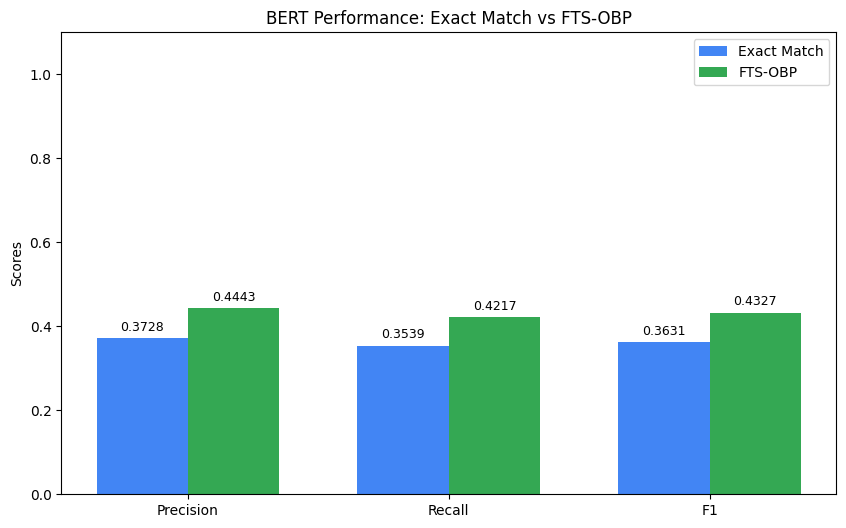


--- 5 MẪU DỰ ĐOÁN ĐẦU TIÊN ---
Review: She will only accept. docx forms in microsoft 2007. But, surprise, mason doesn't use vista or microsoft 2007! They still use XP, and microsoft 2006. This professor is useless and unreasonable. TAKE ANOTHER PROFESSOR
Ref   : (this professor, useless, neutral)
Pred  : (she, will only accept, neutral); (mason, useless and unreasonable, neutral); (this, take another professor, neutral)
----------------------------------------
Review: Great Teacher! Learned a lot! If coming to class isn't your thing take her. But if you do come to class she does know her stuff! Very accommodating and understanding. Good stuff. Highly recommended. Better than the rest!
Ref   : (teacher, great, neutral)
Pred  : (teacher, great, neutral)
----------------------------------------
Review: Not so easy class; great instructor!
Ref   : (class, not so easy, neutral); (instructor, great, neutral)
Pred  : (class, not so easy, neutral); (instructor, great, neutral)
---------------

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import (
    AutoModelForTokenClassification,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
    DataCollatorForTokenClassification
)
from datasets import load_dataset

# =========================================================
# PHẦN 1: HÀM CHUYỂN ĐỔI BIO -> TRIPLET TEXT
# =========================================================

def bio_to_string_triplets(input_ids, label_ids, tokenizer, id2label):
    """
    Chuyển đổi BIO IDs -> List các chuỗi định dạng "(aspect, opinion, sentiment); ..."
    Heuristic: Ghép cặp Aspect và Opinion theo thứ tự xuất hiện (1-1 pairing).
    """
    decoded_list = []
    # Map từ nhãn BIO sang từ chuẩn mà ASTEEvaluator hiểu
    map_sent = {'POS': 'positive', 'NEG': 'negative', 'NEU': 'neutral'}

    for i in range(len(input_ids)):
        tokens = tokenizer.convert_ids_to_tokens(input_ids[i])
        labels = label_ids[i]

        aspects = []
        opinions = [] # Lưu tuple: (opinion_text, sentiment_tag)

        current_entity = []
        current_type = None # 'ASP' hoặc 'OPI'
        current_sent = None # 'POS', 'NEG', 'NEU'

        # --- GIAI ĐOẠN 1: TRÍCH XUẤT THỰC THỂ TỪ BIO ---
        for token, label_id in zip(tokens, labels):
            if label_id == -100: continue
            if token in ["[CLS]", "[SEP]", "[PAD]"]: continue

            # Xử lý subword của BERT (token bắt đầu bằng ##)
            is_subword = token.startswith("##")
            clean_token = token.replace("##", "")

            label = id2label[label_id] # VD: B-OPI-POS

            # Nếu gặp nhãn B- (Bắt đầu thực thể mới)
            if label.startswith("B-"):
                # Lưu thực thể cũ trước đó (nếu có)
                if current_entity:
                    word = " ".join(current_entity).replace(" ##", "") # Join lại
                    # Xử lý lại khoảng trắng thừa do join subword
                    word = word.replace(" .", ".").replace(" ,", ",")

                    if current_type == "ASP": aspects.append(word)
                    elif current_type == "OPI": opinions.append((word, current_sent))

                # Reset bắt đầu thực thể mới
                current_entity = [clean_token]
                parts = label.split("-") # ['B', 'OPI', 'POS']
                current_type = parts[1] # ASP hoặc OPI

                # Lấy sentiment nếu là Opinion
                if current_type == "OPI" and len(parts) > 2:
                    current_sent = parts[2]
                else:
                    current_sent = "NEU" # Mặc định

            # Nếu gặp nhãn I- (Bên trong thực thể) và cùng loại
            elif label.startswith("I-") and current_type == label.split("-")[1]:
                if is_subword:
                    current_entity[-1] += clean_token # Nối liền nếu là subword
                else:
                    current_entity.append(clean_token) # Thêm từ mới

            # Nếu gặp nhãn O hoặc nhãn I sai logic -> Kết thúc thực thể hiện tại
            else:
                if current_entity:
                    word = " ".join(current_entity).replace(" ##", "")
                    if current_type == "ASP": aspects.append(word)
                    elif current_type == "OPI": opinions.append((word, current_sent))
                current_entity = []
                current_type = None

        # Lưu thực thể cuối cùng (nếu còn)
        if current_entity:
            word = " ".join(current_entity).replace(" ##", "")
            if current_type == "ASP": aspects.append(word)
            elif current_type == "OPI": opinions.append((word, current_sent))

        # --- GIAI ĐOẠN 2: GHÉP CẶP (HEURISTIC 1-1) ---
        # BERT Token Classification không biết quan hệ, ta ghép theo thứ tự:
        # Aspect 1 - Opinion 1, Aspect 2 - Opinion 2...
        triplets = []
        min_len = min(len(aspects), len(opinions))

        for j in range(min_len):
            asp = aspects[j]
            opi_text = opinions[j][0]
            raw_sent = opinions[j][1]
            final_sent = map_sent.get(raw_sent, 'neutral')

            # Format chuẩn: (aspect, opinion, sentiment)
            triplets.append(f"({asp}, {opi_text}, {final_sent})")

        decoded_list.append("; ".join(triplets))

    return decoded_list

# =========================================================
# PHẦN 2: LOAD MODEL & PREDICT
# =========================================================

# 1. SETUP LABELS (Phải khớp với lúc train)
label_list = ["O", "B-ASP", "I-ASP", "B-OPI-POS", "I-OPI-POS", "B-OPI-NEG", "I-OPI-NEG", "B-OPI-NEU", "I-OPI-NEU"]
id2label = {i: label for i, label in enumerate(label_list)}
label2id = {label: i for i, label in enumerate(label_list)}

# 2. LOAD MODEL
save_path = "saved_models/bert_aste_final"
print(f"Loading BERT ASTE from: {save_path} ...")

try:
    best_model = AutoModelForTokenClassification.from_pretrained(
        save_path, num_labels=len(label_list), id2label=id2label, label2id=label2id
    ).to("cuda" if torch.cuda.is_available() else "cpu")
    best_tokenizer = AutoTokenizer.from_pretrained(save_path)
except Exception as e:
    print(f"Lỗi: {e}")
    print("⚠️ Kiểm tra lại đường dẫn saved_models/bert_aste_final")
    raise e

# 3. PREDICT
test_args = TrainingArguments(
    output_dir="temp_bert_test",
    do_train=False,
    do_eval=False,
    per_device_eval_batch_size=32 # BERT nhẹ hơn T5, có thể tăng batch size
)
data_collator = DataCollatorForTokenClassification(best_tokenizer)
test_trainer = Trainer(model=best_model, args=test_args, data_collator=data_collator, tokenizer=best_tokenizer)

print("\n--- ĐANG DỰ ĐOÁN VỚI BERT ---")
# LƯU Ý: tokenized_datasets ở đây phải là dataset đã map function của BERT (chứa input_ids, labels, attention_mask)
# Nếu bạn chưa có biến này, hãy đảm bảo chạy lại cell preprocess data cho BERT trước đó.
test_dataset = tokenized_datasets["test"]
predictions_output = test_trainer.predict(test_dataset)

# 4. CONVERT TO TEXT
print("Đang chuyển đổi BIO Tags sang Text Triplets...")
pred_ids = np.argmax(predictions_output.predictions, axis=2)

# Chuyển đổi Prediction
decoded_preds = bio_to_string_triplets(test_dataset['input_ids'], pred_ids, best_tokenizer, id2label)
# Chuyển đổi Ground Truth (Label gốc)
decoded_labels = bio_to_string_triplets(test_dataset['input_ids'], predictions_output.label_ids, best_tokenizer, id2label)

# Lấy text gốc để check FTS (Cần load lại từ raw dataset nếu chưa có)
source_texts = raw_dataset['test']['text']

# =========================================================
# PHẦN 3: ĐÁNH GIÁ (DÙNG CLASS ASTEEvaluator)
# =========================================================

# Khởi tạo Evaluator (dùng chung class với T5)
evaluator = ASTEEvaluator()

# --- A. Exact Match ---
metrics_em = evaluator.compute_scores_exact_match(decoded_preds, decoded_labels)

print("\n" + "="*50)
print(" 📊 KẾT QUẢ 1: EXACT MATCH (BERT - HEURISTIC PAIRING)")
print("="*50)
print(f"Precision : {metrics_em['precision']:.4f}")
print(f"Recall    : {metrics_em['recall']:.4f}")
print(f"F1-Score  : {metrics_em['f1']:.4f}")
print(f"TP: {metrics_em['tp']}, FP: {metrics_em['fp']}, FN: {metrics_em['fn']}")

# --- B. FTS-OBP ---
metrics_fts = evaluator.compute_scores_fts_obp(decoded_preds, decoded_labels, source_texts)

print("\n" + "="*50)
print(" 📊 KẾT QUẢ 2: FTS-OBP (BERT)")
print("="*50)
print(f"Precision : {metrics_fts['precision']:.4f}")
print(f"Recall    : {metrics_fts['recall']:.4f}")
print(f"F1-Score  : {metrics_fts['f1']:.4f}")
print(f"TP: {metrics_fts['tp']}, FP: {metrics_fts['fp']}, FN: {metrics_fts['fn']}")
print("-" * 50)

# --- C. Biểu đồ ---
metrics_names = ['Precision', 'Recall', 'F1']
x = np.arange(len(metrics_names))
width = 0.35

vals_em = [metrics_em['precision'], metrics_em['recall'], metrics_em['f1']]
vals_fts = [metrics_fts['precision'], metrics_fts['recall'], metrics_fts['f1']]

plt.figure(figsize=(10, 6))
bar1 = plt.bar(x - width/2, vals_em, width, label='Exact Match', color='#4285F4')
bar2 = plt.bar(x + width/2, vals_fts, width, label='FTS-OBP', color='#34A853')

plt.ylabel('Scores')
plt.title('BERT Performance: Exact Match vs FTS-OBP')
plt.xticks(x, metrics_names)
plt.legend()
plt.ylim(0, 1.1)

def add_labels(bars):
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 4), ha='center', va='bottom', fontsize=9)

add_labels(bar1)
add_labels(bar2)
plt.show()

# 5. IN MẪU KẾT QUẢ ĐỂ DEBUG
print("\n--- 5 MẪU DỰ ĐOÁN ĐẦU TIÊN ---")
for i in range(5):
    print(f"Review: {source_texts[i]}")
    print(f"Ref   : {decoded_labels[i]}")
    print(f"Pred  : {decoded_preds[i]}")
    print("-" * 40)

#####1_4. Test thử một vài mẫu

In [ ]:
import random

# Đảm bảo hàm parse_aste_triplets đã được định nghĩa
if 'parse_aste_triplets' not in globals():
    import re
    def parse_aste_triplets(text):
        triplets = set()
        try:
            matches = re.findall(r'\(([^,]+),([^,]+),([^)]+)\)', text)
            for match in matches:
                asp = match[0].strip().lower()
                opi = match[1].strip().lower()
                sent = match[2].strip().lower()
                triplets.add((asp, opi, sent))
        except:
            pass
        return triplets

print("\n--- KIỂM TRA MẪU NGẪU NHIÊN TỪ TẬP TEST (BERT - ASTE) ---")

# 1. Chọn ngẫu nhiên mẫu
num_samples = 5
total_samples = len(decoded_preds)
random_indices = random.sample(range(total_samples), min(num_samples, total_samples))

# 2. Lấy input gốc từ dataset (để hiển thị text gốc)
# Lưu ý: test_dataset phải là biến dataset bạn dùng để predict ở bước trước
raw_input_ids = test_dataset['input_ids']

for i in random_indices:
    # Decode Input gốc (BERT tokenizer sẽ tự bỏ [CLS], [SEP])
    input_text = best_tokenizer.decode(raw_input_ids[i], skip_special_tokens=True)

    # Lấy kết quả đã convert từ BIO -> String Triplet ở bước trước
    pred = decoded_preds[i]
    label = decoded_labels[i]

    print(f"\nExample #{i}:")
    print(f"📝 Review Text: {input_text}")
    print(f"✅ Ground Truth: {label}")
    print(f"🤖 Prediction  : {pred}")

    # 3. So sánh bằng hàm parse_aste_triplets (Quan trọng: So sánh bộ 3)
    try:
        pred_triplets = parse_aste_triplets(pred)
        label_triplets = parse_aste_triplets(label)

        # So sánh set để không quan trọng thứ tự xuất hiện trong chuỗi
        if pred_triplets == label_triplets:
            print("=> Đánh giá: CHÍNH XÁC HOÀN TOÀN 🎉")
        else:
            print("=> Đánh giá: SAI ❌")

            # Phân tích lỗi chi tiết để debug
            missing = label_triplets - pred_triplets
            extra = pred_triplets - label_triplets

            if missing:
                print(f"   ⚠️  Thiếu (FN): {missing}")
            if extra:
                print(f"   ⚠️  Thừa/Sai (FP): {extra}")

    except Exception as e:
        print(f"⚠️ Lỗi khi parse: {e}")

    print("-" * 60)


--- KIỂM TRA MẪU NGẪU NHIÊN TỪ TẬP TEST (BERT - ASTE) ---

Example #571:
📝 Review Text: incredibly enthusiastic. very nice guy willing to work with you to make sure you can do your very best. i loved attending this class.
✅ Ground Truth: (this class, incredibly enthusiastic, neutral)
🤖 Prediction  : (this class, incredibly enthusiastic, neutral)
=> Đánh giá: CHÍNH XÁC HOÀN TOÀN 🎉
------------------------------------------------------------

Example #419:
📝 Review Text: perfect course note, very easy to understand.
✅ Ground Truth: (course note, perfect, neutral)
🤖 Prediction  : (course note, perfect, neutral)
=> Đánh giá: CHÍNH XÁC HOÀN TOÀN 🎉
------------------------------------------------------------

Example #2233:
📝 Review Text: probably my favourite course in 1a. easy to do well in the course and the staff put the learning materials together really well. really enjoyed this course since it teaches you about the art of problem - solving and the creative components of mathematics. 

---